In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from scipy.integrate import solve_ivp
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SCENARIO = "motor_lr_m1_left"
SNR_NAME = "snr_5"
REPLICATE = 1

NOISY_FILE = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "noisy"
    / SCENARIO
    / SNR_NAME
    / (
        f"{SCENARIO}_"
        f"{SNR_NAME}_"
        f"rep_{REPLICATE:02d}.csv"
    )
)

EVENT_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "100206"
    / "MNINonLinear"
    / "Results"
    / "tfMRI_MOTOR_LR"
    / "EVs"
    / "rh.txt"
)

GROUND_TRUTH_PARAMETERS_PATH = (
    PROJECT_ROOT
    / "configs"
    / "synthetic_ground_truth.json"
)

GROUND_TRUTH_HRF_PATH = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "ground_truth_hrf.csv"
)

PILOT_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "pinn_pilot"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

PILOT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Datos ruidosos:", NOISY_FILE.exists())
print("Eventos:", EVENT_FILE.exists())
print(
    "Parámetros verdaderos:",
    GROUND_TRUTH_PARAMETERS_PATH.exists(),
)
print("HRF verdadera:", GROUND_TRUTH_HRF_PATH.exists())

Datos ruidosos: True
Eventos: True
Parámetros verdaderos: True
HRF verdadera: True


In [4]:
data = pd.read_csv(
    NOISY_FILE
)

event_values = np.loadtxt(
    EVENT_FILE,
    ndmin=2,
)

events = pd.DataFrame(
    {
        "onset_s": event_values[:, 0],
        "duration_s": event_values[:, 1],
        "amplitude": event_values[:, 2],
    }
)

with open(
    GROUND_TRUTH_PARAMETERS_PATH,
    encoding="utf-8",
) as file:
    ground_truth_parameters = json.load(file)

ground_truth_hrf = pd.read_csv(
    GROUND_TRUTH_HRF_PATH
)

time_s = data["time_s"].to_numpy(
    dtype=np.float32
)

noisy_bold = data[
    "bold_noisy_fraction"
].to_numpy(
    dtype=np.float32
)

clean_bold = data[
    "bold_clean_fraction"
].to_numpy(
    dtype=np.float32
)

train_mask = data[
    "train_mask"
].to_numpy(
    dtype=bool
)

test_mask = data[
    "test_mask"
].to_numpy(
    dtype=bool
)

print("Puntos totales:", len(data))
print("Entrenamiento:", train_mask.sum())
print("Evaluación:", test_mask.sum())

display(events)

Puntos totales: 284
Entrenamiento: 237
Evaluación: 47


,onset_s,duration_s,amplitude
0,11.009,12.0,1.0
1,131.892,12.0,1.0


In [5]:
RANDOM_SEED = 20260717

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

torch.use_deterministic_algorithms(
    True,
    warn_only=True,
)

torch.set_default_dtype(
    torch.float32
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", DEVICE)

Dispositivo: cuda


In [6]:
PINN_CONFIG = {
    "hidden_layers": [48, 48, 48],
    "phase_1_epochs": 800,
    "phase_2_epochs": 2200,
    "phase_1_learning_rate": 1e-3,
    "phase_2_network_learning_rate": 5e-4,
    "phase_2_parameter_learning_rate": 1e-3,
    "lambda_data": 1.0,
    "lambda_physics_start": 0.10,
    "lambda_physics_final": 1.0,
    "lambda_initial_condition": 25.0,
    "n_dense_collocation": 420,
    "boundary_exclusion_s": 0.08,
}

INITIAL_PARAMETER_VALUES = {
    "epsilon": 0.10,
    "tau": 1.30,
    "alpha": 0.42,
}

PARAMETER_BOUNDS = {
    "epsilon": (0.05, 0.30),
    "tau": (0.50, 2.00),
    "alpha": (0.15, 0.60),
}

with open(
    PILOT_RESULTS_DIR
    / "pinn_pilot_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            **PINN_CONFIG,
            "initial_parameters": INITIAL_PARAMETER_VALUES,
            "parameter_bounds": PARAMETER_BOUNDS,
        },
        file,
        indent=2,
        ensure_ascii=False,
    )

In [7]:
def logit(
    probability: float,
) -> float:
    probability = np.clip(
        probability,
        1e-6,
        1.0 - 1e-6,
    )

    return float(
        np.log(
            probability
            / (1.0 - probability)
        )
    )

In [8]:
class BoundedScalar(nn.Module):
    """
    Parámetro entrenable restringido entre
    límites fisiológicos.
    """

    def __init__(
        self,
        lower: float,
        upper: float,
        initial: float,
    ):
        super().__init__()

        if not lower < initial < upper:
            raise ValueError(
                "El valor inicial debe estar "
                "dentro de los límites."
            )

        self.lower = float(lower)
        self.upper = float(upper)

        normalized_initial = (
            (initial - lower)
            / (upper - lower)
        )

        raw_initial = logit(
            normalized_initial
        )

        self.raw = nn.Parameter(
            torch.tensor(
                raw_initial,
                dtype=torch.float32,
            )
        )

    def forward(
        self,
    ) -> torch.Tensor:
        return (
            self.lower
            + (
                self.upper
                - self.lower
            )
            * torch.sigmoid(
                self.raw
            )
        )

In [9]:
class BalloonWindkesselPINN(nn.Module):
    """
    PINN que recibe el tiempo y estima:
        s(t), f(t), v(t), q(t)

    La señal BOLD se calcula mediante la
    ecuación fisiológica de observación.
    """

    def __init__(
        self,
        maximum_time_s: float,
    ):
        super().__init__()

        self.maximum_time_s = float(
            maximum_time_s
        )

        dimensions = [
            1,
            *PINN_CONFIG["hidden_layers"],
            4,
        ]

        layers = []

        for input_size, output_size in zip(
            dimensions[:-2],
            dimensions[1:-1],
        ):
            layers.append(
                nn.Linear(
                    input_size,
                    output_size,
                )
            )

            layers.append(
                nn.Tanh()
            )

        layers.append(
            nn.Linear(
                dimensions[-2],
                dimensions[-1],
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        # Inicialmente todos los estados están
        # próximos a su condición basal.
        final_layer = self.network[-1]

        nn.init.zeros_(
            final_layer.weight
        )

        nn.init.zeros_(
            final_layer.bias
        )

        self.epsilon = BoundedScalar(
            *PARAMETER_BOUNDS["epsilon"],
            INITIAL_PARAMETER_VALUES["epsilon"],
        )

        self.tau = BoundedScalar(
            *PARAMETER_BOUNDS["tau"],
            INITIAL_PARAMETER_VALUES["tau"],
        )

        self.alpha = BoundedScalar(
            *PARAMETER_BOUNDS["alpha"],
            INITIAL_PARAMETER_VALUES["alpha"],
        )

    def states(
        self,
        time_tensor: torch.Tensor,
    ):
        normalized_time = (
            2.0
            * time_tensor
            / self.maximum_time_s
            - 1.0
        )

        raw_states = self.network(
            normalized_time
        )

        # Transformaciones que mantienen los
        # estados en intervalos fisiológicos.
        s = (
            0.50
            * torch.tanh(
                raw_states[:, 0:1]
            )
        )

        f = (
            1.0
            + 0.80
            * torch.tanh(
                raw_states[:, 1:2]
            )
        )

        v = (
            1.0
            + 0.35
            * torch.tanh(
                raw_states[:, 2:3]
            )
        )

        q = (
            1.0
            + 0.35
            * torch.tanh(
                raw_states[:, 3:4]
            )
        )

        return s, f, v, q

    def parameter_values(
        self,
    ):
        return {
            "epsilon": self.epsilon(),
            "tau": self.tau(),
            "alpha": self.alpha(),
        }

    def bold(
        self,
        time_tensor: torch.Tensor,
    ):
        _, _, v, q = self.states(
            time_tensor
        )

        E0 = 0.34
        V0 = 0.02

        k1 = 7.0 * E0
        k2 = 2.0
        k3 = 2.0 * E0 - 0.2

        bold_fraction = V0 * (
            k1 * (1.0 - q)
            + k2 * (
                1.0 - q / v
            )
            + k3 * (1.0 - v)
        )

        return bold_fraction

In [10]:
EVENT_ONSETS = torch.tensor(
    events["onset_s"].to_numpy(),
    dtype=torch.float32,
    device=DEVICE,
)

EVENT_DURATIONS = torch.tensor(
    events["duration_s"].to_numpy(),
    dtype=torch.float32,
    device=DEVICE,
)

EVENT_AMPLITUDES = torch.tensor(
    events["amplitude"].to_numpy(),
    dtype=torch.float32,
    device=DEVICE,
)

In [11]:
def stimulus_torch(
    time_tensor: torch.Tensor,
) -> torch.Tensor:
    stimulus = torch.zeros_like(
        time_tensor
    )

    for onset, duration, amplitude in zip(
        EVENT_ONSETS,
        EVENT_DURATIONS,
        EVENT_AMPLITUDES,
    ):
        active = (
            (time_tensor >= onset)
            & (
                time_tensor
                < onset + duration
            )
        )

        stimulus = (
            stimulus
            + amplitude
            * active.to(
                time_tensor.dtype
            )
        )

    return stimulus

In [12]:
def time_derivative(
    output: torch.Tensor,
    time_tensor: torch.Tensor,
) -> torch.Tensor:
    return torch.autograd.grad(
        outputs=output,
        inputs=time_tensor,
        grad_outputs=torch.ones_like(
            output
        ),
        create_graph=True,
        retain_graph=True,
    )[0]

In [19]:
def physical_residuals(
    model: BalloonWindkesselPINN,
    collocation_times: torch.Tensor,
):
    times = (
        collocation_times
        .detach()
        .clone()
        .requires_grad_(True)
    )

    s, f, v, q = model.states(
        times
    )

    ds_dt = time_derivative(
        s,
        times,
    )

    df_dt = time_derivative(
        f,
        times,
    )

    dv_dt = time_derivative(
        v,
        times,
    )

    dq_dt = time_derivative(
        q,
        times,
    )

    parameters = (
        model.parameter_values()
    )

    epsilon = parameters["epsilon"]
    tau = parameters["tau"]
    alpha = parameters["alpha"]

    kappa_s = 0.65
    kappa_f = 0.41
    E0 = 0.34

    neural_input = stimulus_torch(
        times
    )

    extraction = (
        1.0
        - torch.pow(
            torch.tensor(
                1.0 - E0,
                dtype=times.dtype,
                device=times.device,
            ),
            1.0 / f,
        )
    )

    residual_s = (
        ds_dt
        - (
            epsilon * neural_input
            - kappa_s * s
            - kappa_f * (f - 1.0)
        )
    )

    residual_f = (
        df_dt - s
    )

    residual_v = (
        tau * dv_dt
        - (
            f
            - torch.pow(
                v,
                1.0 / alpha,
            )
        )
    )

    residual_q = (
        tau * dq_dt
        - (
            f * extraction / E0
            - torch.pow(
                v,
                1.0 / alpha,
            )
            * q / v
        )
    )

    return {
        "s": residual_s,
        "f": residual_f,
        "v": residual_v,
        "q": residual_q,
    }

In [20]:
maximum_time_s = float(
    time_s[-1]
)

dense_collocation = np.linspace(
    0.0,
    maximum_time_s,
    PINN_CONFIG[
        "n_dense_collocation"
    ],
    dtype=np.float32,
)

event_boundaries = np.concatenate(
    [
        events["onset_s"].to_numpy(),
        (
            events["onset_s"]
            + events["duration_s"]
        ).to_numpy(),
    ]
)

all_collocation = np.unique(
    np.concatenate(
        [
            dense_collocation,
            time_s,
        ]
    )
)

# La entrada neuronal es discontinua justo
# en los límites de los bloques. Se evita
# imponer la derivada exactamente allí.
for boundary in event_boundaries:
    all_collocation = (
        all_collocation[
            np.abs(
                all_collocation
                - boundary
            )
            > PINN_CONFIG[
                "boundary_exclusion_s"
            ]
        ]
    )

all_collocation = np.unique(
    np.concatenate(
        [
            np.array(
                [0.0],
                dtype=np.float32,
            ),
            all_collocation,
        ]
    )
)

collocation_tensor = torch.tensor(
    all_collocation[:, None],
    dtype=torch.float32,
    device=DEVICE,
)

train_time_tensor = torch.tensor(
    time_s[train_mask, None],
    dtype=torch.float32,
    device=DEVICE,
)

train_bold_tensor = torch.tensor(
    noisy_bold[train_mask, None],
    dtype=torch.float32,
    device=DEVICE,
)

data_scale = float(
    np.std(
        noisy_bold[train_mask],
        ddof=0,
    )
)

print(
    "Puntos de colocación:",
    len(all_collocation),
)

print(
    "Escala BOLD de entrenamiento:",
    data_scale,
)

Puntos de colocación: 700
Escala BOLD de entrenamiento: 0.003843297716230154


In [21]:
def calculate_losses(
    model: BalloonWindkesselPINN,
    lambda_physics: float,
):
    predicted_bold = model.bold(
        train_time_tensor
    )

    data_loss = torch.mean(
        (
            (
                predicted_bold
                - train_bold_tensor
            )
            / data_scale
        ) ** 2
    )

    residuals = physical_residuals(
        model,
        collocation_tensor,
    )

    # Los residuos se dividen por una escala
    # común para equilibrar la optimización.
    residual_scale = 0.15

    physics_loss = sum(
        torch.mean(
            (
                residual
                / residual_scale
            ) ** 2
        )
        for residual in residuals.values()
    )

    initial_time = torch.zeros(
        (1, 1),
        dtype=torch.float32,
        device=DEVICE,
    )

    s0, f0, v0, q0 = model.states(
        initial_time
    )

    initial_condition_loss = (
        torch.mean(s0**2)
        + torch.mean(
            (f0 - 1.0) ** 2
        )
        + torch.mean(
            (v0 - 1.0) ** 2
        )
        + torch.mean(
            (q0 - 1.0) ** 2
        )
    )

    total_loss = (
        PINN_CONFIG["lambda_data"]
        * data_loss
        + lambda_physics
        * physics_loss
        + PINN_CONFIG[
            "lambda_initial_condition"
        ]
        * initial_condition_loss
    )

    return {
        "total": total_loss,
        "data": data_loss,
        "physics": physics_loss,
        "initial": initial_condition_loss,
    }

In [22]:
def train_phase(
    model: BalloonWindkesselPINN,
    optimizer: torch.optim.Optimizer,
    n_epochs: int,
    phase_name: str,
    lambda_physics_start: float,
    lambda_physics_final: float,
):
    history = []

    best_loss = np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(
        1,
        n_epochs + 1,
    ):
        progress = (
            (epoch - 1)
            / max(n_epochs - 1, 1)
        )

        lambda_physics = (
            lambda_physics_start
            + progress
            * (
                lambda_physics_final
                - lambda_physics_start
            )
        )

        model.train()
        optimizer.zero_grad()

        losses = calculate_losses(
            model,
            lambda_physics=lambda_physics,
        )

        if not torch.isfinite(
            losses["total"]
        ):
            raise RuntimeError(
                "La pérdida dejó de ser finita."
            )

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        total_value = float(
            losses["total"]
            .detach()
            .cpu()
        )

        parameter_values = {
            name: float(
                value.detach().cpu()
            )
            for name, value in (
                model.parameter_values()
            ).items()
        }

        history.append(
            {
                "phase": phase_name,
                "epoch": epoch,
                "lambda_physics": lambda_physics,
                "total_loss": total_value,
                "data_loss": float(
                    losses["data"]
                    .detach()
                    .cpu()
                ),
                "physics_loss": float(
                    losses["physics"]
                    .detach()
                    .cpu()
                ),
                "initial_loss": float(
                    losses["initial"]
                    .detach()
                    .cpu()
                ),
                **parameter_values,
            }
        )

        if total_value < best_loss:
            best_loss = total_value
            best_state = copy.deepcopy(
                model.state_dict()
            )

        if (
            epoch == 1
            or epoch % 250 == 0
            or epoch == n_epochs
        ):
            print(
                f"{phase_name} | "
                f"{epoch:4d}/{n_epochs} | "
                f"L={total_value:.5f} | "
                f"Ldata={history[-1]['data_loss']:.5f} | "
                f"Lphys={history[-1]['physics_loss']:.5f} | "
                f"epsilon={parameter_values['epsilon']:.4f} | "
                f"tau={parameter_values['tau']:.4f} | "
                f"alpha={parameter_values['alpha']:.4f}"
            )

    if best_state is None:
        raise RuntimeError(
            "No se almacenó un estado válido."
        )

    model.load_state_dict(
        best_state
    )

    elapsed_time = (
        time.time() - start_time
    )

    print(
        f"{phase_name} completada en "
        f"{elapsed_time / 60.0:.2f} min."
    )

    return pd.DataFrame(history)

In [23]:
model = BalloonWindkesselPINN(
    maximum_time_s=maximum_time_s
).to(DEVICE)

In [24]:
model.epsilon.raw.requires_grad_(False)
model.tau.raw.requires_grad_(False)
model.alpha.raw.requires_grad_(False)

optimizer_phase_1 = torch.optim.Adam(
    model.network.parameters(),
    lr=PINN_CONFIG[
        "phase_1_learning_rate"
    ],
)

history_phase_1 = train_phase(
    model=model,
    optimizer=optimizer_phase_1,
    n_epochs=PINN_CONFIG[
        "phase_1_epochs"
    ],
    phase_name="fixed_parameters",
    lambda_physics_start=PINN_CONFIG[
        "lambda_physics_start"
    ],
    lambda_physics_final=PINN_CONFIG[
        "lambda_physics_final"
    ],
)

fixed_parameters |    1/800 | L=1.07343 | Ldata=1.06829 | Lphys=0.05143 | epsilon=0.1000 | tau=1.3000 | alpha=0.4200
fixed_parameters |  250/800 | L=0.16973 | Ldata=0.14791 | Lphys=0.04442 | epsilon=0.1000 | tau=1.3000 | alpha=0.4200
fixed_parameters |  500/800 | L=0.09358 | Ldata=0.06893 | Lphys=0.03700 | epsilon=0.1000 | tau=1.3000 | alpha=0.4200
fixed_parameters |  750/800 | L=0.09316 | Ldata=0.06041 | Lphys=0.03453 | epsilon=0.1000 | tau=1.3000 | alpha=0.4200
fixed_parameters |  800/800 | L=0.09352 | Ldata=0.05982 | Lphys=0.03362 | epsilon=0.1000 | tau=1.3000 | alpha=0.4200
fixed_parameters completada en 0.23 min.


In [25]:
model.epsilon.raw.requires_grad_(True)
model.tau.raw.requires_grad_(True)
model.alpha.raw.requires_grad_(True)

optimizer_phase_2 = torch.optim.Adam(
    [
        {
            "params": model.network.parameters(),
            "lr": PINN_CONFIG[
                "phase_2_network_learning_rate"
            ],
        },
        {
            "params": [
                model.epsilon.raw,
                model.tau.raw,
                model.alpha.raw,
            ],
            "lr": PINN_CONFIG[
                "phase_2_parameter_learning_rate"
            ],
        },
    ]
)

history_phase_2 = train_phase(
    model=model,
    optimizer=optimizer_phase_2,
    n_epochs=PINN_CONFIG[
        "phase_2_epochs"
    ],
    phase_name="inverse_problem",
    lambda_physics_start=1.0,
    lambda_physics_final=1.0,
)

inverse_problem |    1/2200 | L=0.09888 | Ldata=0.06273 | Lphys=0.03596 | epsilon=0.1000 | tau=1.2996 | alpha=0.4199
inverse_problem |  250/2200 | L=0.08857 | Ldata=0.05872 | Lphys=0.02974 | epsilon=0.0912 | tau=1.2068 | alpha=0.3949
inverse_problem |  500/2200 | L=0.08058 | Ldata=0.05659 | Lphys=0.02396 | epsilon=0.0851 | tau=1.1274 | alpha=0.3720
inverse_problem |  750/2200 | L=0.07431 | Ldata=0.05489 | Lphys=0.01938 | epsilon=0.0806 | tau=1.0609 | alpha=0.3492
inverse_problem | 1000/2200 | L=0.06948 | Ldata=0.05385 | Lphys=0.01560 | epsilon=0.0775 | tau=1.0034 | alpha=0.3277
inverse_problem | 1250/2200 | L=0.06597 | Ldata=0.05296 | Lphys=0.01299 | epsilon=0.0754 | tau=0.9527 | alpha=0.3091
inverse_problem | 1500/2200 | L=0.06402 | Ldata=0.05288 | Lphys=0.01109 | epsilon=0.0740 | tau=0.9086 | alpha=0.2937
inverse_problem | 1750/2200 | L=0.06167 | Ldata=0.05199 | Lphys=0.00963 | epsilon=0.0732 | tau=0.8704 | alpha=0.2804
inverse_problem | 2000/2200 | L=0.06348 | Ldata=0.05407 | Lphys=

In [26]:
complete_time_tensor = torch.tensor(
    time_s[:, None],
    dtype=torch.float32,
    device=DEVICE,
)

model.eval()

with torch.no_grad():
    predicted_bold = (
        model.bold(
            complete_time_tensor
        )
        .cpu()
        .numpy()
        .reshape(-1)
    )

    predicted_states = (
        model.states(
            complete_time_tensor
        )
    )

    predicted_s = (
        predicted_states[0]
        .cpu()
        .numpy()
        .reshape(-1)
    )

    predicted_f = (
        predicted_states[1]
        .cpu()
        .numpy()
        .reshape(-1)
    )

    predicted_v = (
        predicted_states[2]
        .cpu()
        .numpy()
        .reshape(-1)
    )

    predicted_q = (
        predicted_states[3]
        .cpu()
        .numpy()
        .reshape(-1)
    )

In [27]:
def calculate_metrics(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    mse = mean_squared_error(
        observed,
        predicted,
    )

    return {
        "rmse_percent": float(
            100.0 * np.sqrt(mse)
        ),
        "mae_percent": float(
            100.0
            * mean_absolute_error(
                observed,
                predicted,
            )
        ),
        "r2": float(
            r2_score(
                observed,
                predicted,
            )
        ),
        "pearson_r": float(
            np.corrcoef(
                observed,
                predicted,
            )[0, 1]
        ),
    }

In [28]:
test_metrics = calculate_metrics(
    clean_bold[test_mask],
    predicted_bold[test_mask],
)

print("Métricas PINN en evaluación:")
display(
    pd.DataFrame(
        [test_metrics]
    )
)

Métricas PINN en evaluación:


,rmse_percent,mae_percent,r2,pearson_r
0,0.594728,0.423395,0.28694,0.915182


In [29]:
estimated_parameters = {
    name: float(
        value.detach().cpu()
    )
    for name, value in (
        model.parameter_values()
    ).items()
}

parameter_rows = []

for parameter_name in [
    "epsilon",
    "tau",
    "alpha",
]:
    true_value = float(
        ground_truth_parameters[
            parameter_name
        ]
    )

    initial_value = float(
        INITIAL_PARAMETER_VALUES[
            parameter_name
        ]
    )

    estimated_value = float(
        estimated_parameters[
            parameter_name
        ]
    )

    parameter_rows.append(
        {
            "parameter": parameter_name,
            "true_value": true_value,
            "initial_value": initial_value,
            "estimated_value": estimated_value,
            "absolute_error": abs(
                estimated_value
                - true_value
            ),
            "relative_error_percent": (
                100.0
                * abs(
                    estimated_value
                    - true_value
                )
                / abs(true_value)
            ),
        }
    )

parameter_table = pd.DataFrame(
    parameter_rows
)

display(parameter_table)

,parameter,true_value,initial_value,estimated_value,absolute_error,relative_error_percent
0,epsilon,0.15,0.10,0.072602,0.077398,51.598699
1,tau,0.98,1.30,0.814488,0.165512,16.888938
2,alpha,0.32,0.42,0.259263,0.060737,18.980440


In [30]:
state_rows = []

state_predictions = {
    "s": predicted_s,
    "f": predicted_f,
    "v": predicted_v,
    "q": predicted_q,
}

for state_name, prediction in (
    state_predictions.items()
):
    true_state = data[
        state_name
    ].to_numpy(
        dtype=float
    )

    state_rows.append(
        {
            "state": state_name,
            "rmse_all": float(
                np.sqrt(
                    mean_squared_error(
                        true_state,
                        prediction,
                    )
                )
            ),
            "r2_all": float(
                r2_score(
                    true_state,
                    prediction,
                )
            ),
            "rmse_test": float(
                np.sqrt(
                    mean_squared_error(
                        true_state[test_mask],
                        prediction[test_mask],
                    )
                )
            ),
            "r2_test": float(
                r2_score(
                    true_state[test_mask],
                    prediction[test_mask],
                )
            ),
        }
    )

state_metrics = pd.DataFrame(
    state_rows
)

display(state_metrics)

,state,rmse_all,r2_all,rmse_test,r2_test
0,s,0.021358,0.434770,0.047273,0.083040
1,f,0.066465,0.679691,0.151020,0.250013
2,v,0.021095,0.606563,0.046255,0.140713
3,q,0.023948,0.735985,0.057958,0.284313


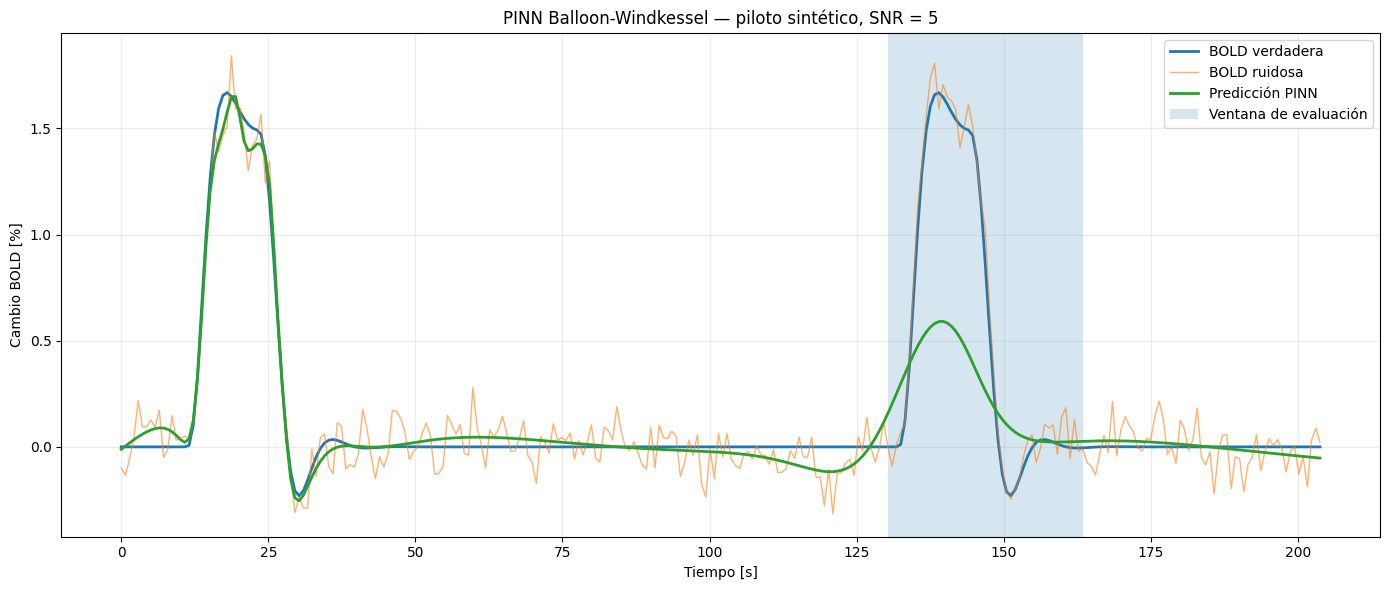

In [31]:
test_times = time_s[test_mask]

plt.figure(figsize=(14, 6))

plt.plot(
    time_s,
    100.0 * clean_bold,
    linewidth=2.0,
    label="BOLD verdadera",
)

plt.plot(
    time_s,
    100.0 * noisy_bold,
    linewidth=1.0,
    alpha=0.60,
    label="BOLD ruidosa",
)

plt.plot(
    time_s,
    100.0 * predicted_bold,
    linewidth=2.0,
    label="Predicción PINN",
)

plt.axvspan(
    float(test_times.min()),
    float(test_times.max()),
    alpha=0.18,
    label="Ventana de evaluación",
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "PINN Balloon-Windkessel — piloto sintético, SNR = 5"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

pilot_figure_path = (
    FIGURES_DIR
    / "pinn_pilot_prediction_snr5.png"
)

plt.savefig(
    pilot_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

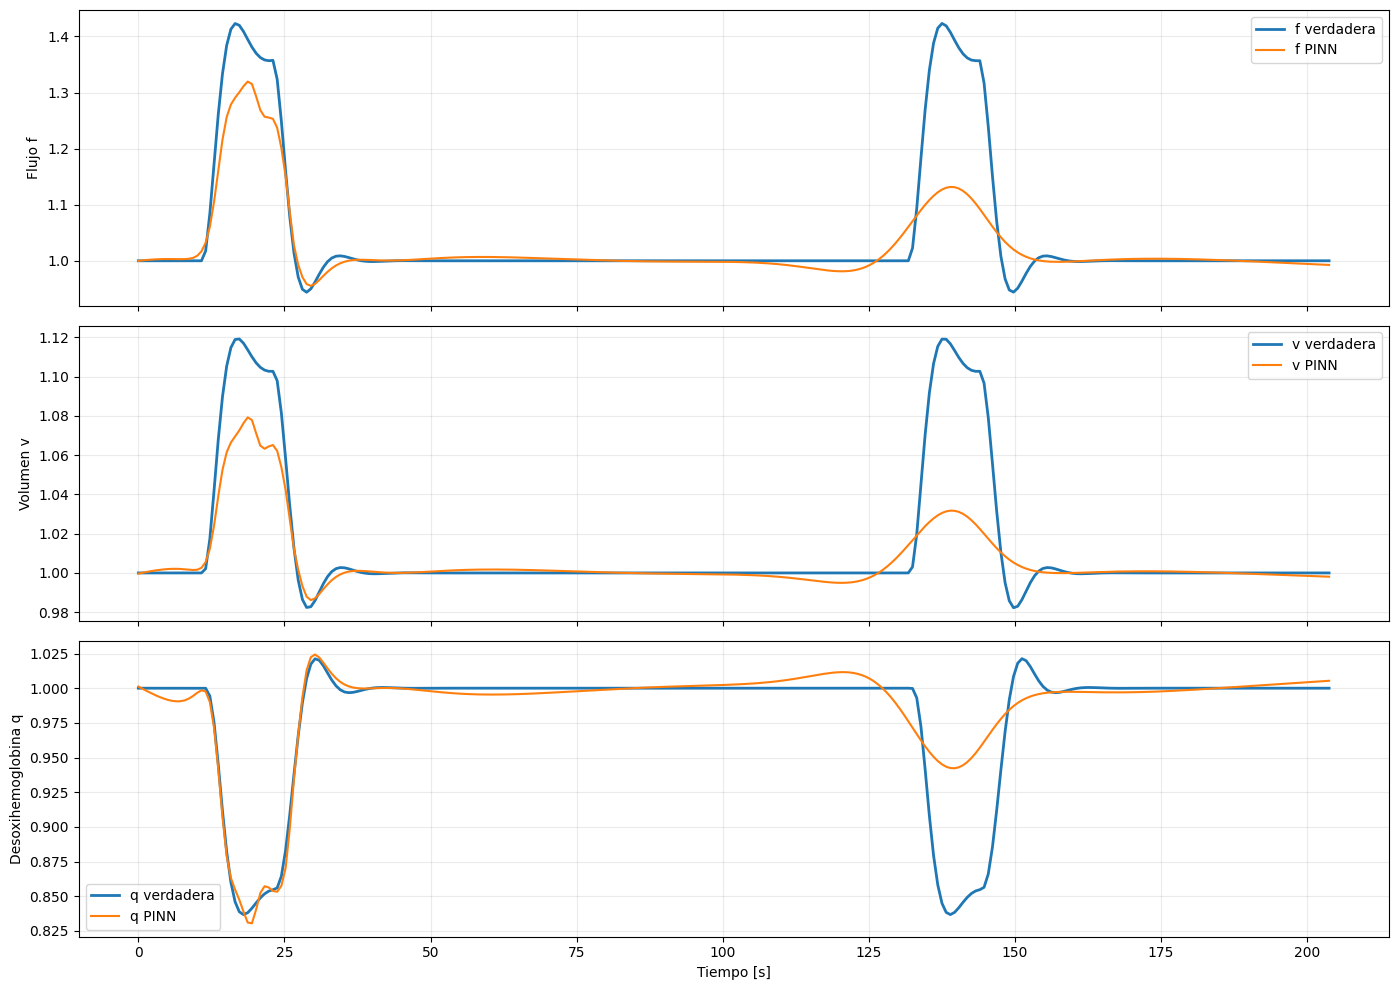

In [32]:
figure, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True,
)

axes[0].plot(
    time_s,
    data["f"],
    label="f verdadera",
    linewidth=2.0,
)

axes[0].plot(
    time_s,
    predicted_f,
    label="f PINN",
    linewidth=1.5,
)

axes[0].set_ylabel("Flujo f")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    time_s,
    data["v"],
    label="v verdadera",
    linewidth=2.0,
)

axes[1].plot(
    time_s,
    predicted_v,
    label="v PINN",
    linewidth=1.5,
)

axes[1].set_ylabel("Volumen v")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    time_s,
    data["q"],
    label="q verdadera",
    linewidth=2.0,
)

axes[2].plot(
    time_s,
    predicted_q,
    label="q PINN",
    linewidth=1.5,
)

axes[2].set_xlabel("Tiempo [s]")
axes[2].set_ylabel("Desoxihemoglobina q")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()

states_figure_path = (
    FIGURES_DIR
    / "pinn_pilot_latent_states_snr5.png"
)

plt.savefig(
    states_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [33]:
training_history = pd.concat(
    [
        history_phase_1,
        history_phase_2,
    ],
    ignore_index=True,
)

prediction_table = pd.DataFrame(
    {
        "time_s": time_s,
        "clean_fraction": clean_bold,
        "noisy_fraction": noisy_bold,
        "predicted_fraction": predicted_bold,
        "true_s": data["s"],
        "predicted_s": predicted_s,
        "true_f": data["f"],
        "predicted_f": predicted_f,
        "true_v": data["v"],
        "predicted_v": predicted_v,
        "true_q": data["q"],
        "predicted_q": predicted_q,
        "train_mask": train_mask.astype(int),
        "test_mask": test_mask.astype(int),
    }
)

training_history.to_csv(
    PILOT_RESULTS_DIR
    / "pinn_pilot_training_history.csv",
    index=False,
)

prediction_table.to_csv(
    PILOT_RESULTS_DIR
    / "pinn_pilot_predictions.csv",
    index=False,
)

parameter_table.to_csv(
    PILOT_RESULTS_DIR
    / "pinn_pilot_parameters.csv",
    index=False,
)

state_metrics.to_csv(
    PILOT_RESULTS_DIR
    / "pinn_pilot_state_metrics.csv",
    index=False,
)

pd.DataFrame(
    [test_metrics]
).to_csv(
    PILOT_RESULTS_DIR
    / "pinn_pilot_test_metrics.csv",
    index=False,
)

torch.save(
    {
        "model_state_dict": (
            model.state_dict()
        ),
        "configuration": PINN_CONFIG,
        "scenario": SCENARIO,
        "snr_name": SNR_NAME,
        "replicate": REPLICATE,
    },
    PILOT_RESULTS_DIR
    / "pinn_pilot_model.pt",
)

print(
    "Resultados guardados en:",
    PILOT_RESULTS_DIR,
)

Resultados guardados en: /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/pinn_pilot
